Audio Level: 
Stopped.


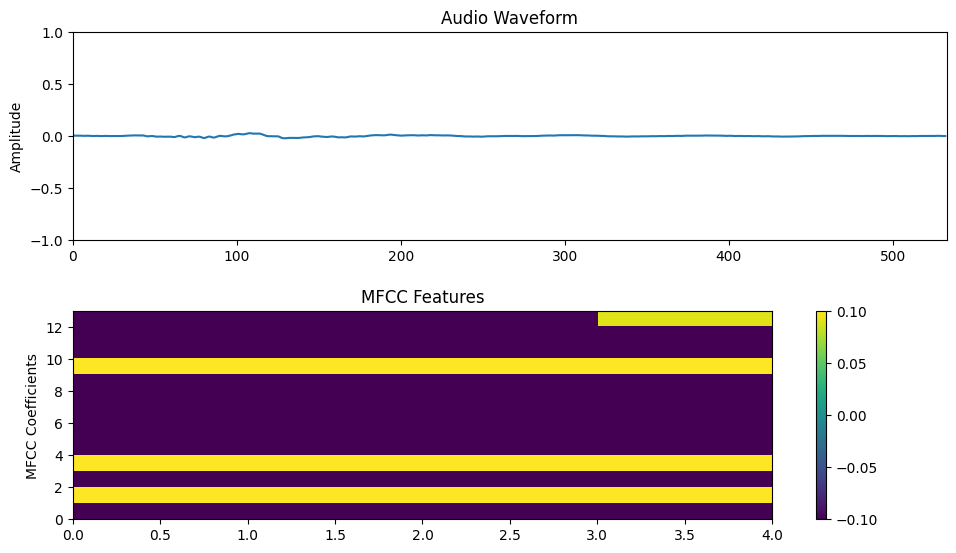

In [28]:
import torch
import torchaudio
import sounddevice as sd
import numpy as np
import time
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import clear_output

# === Audio settings ===
SAMPLE_RATE = 16000
FRAME_RATE = 30  # 30 fps
FRAME_DURATION = 1.0 / FRAME_RATE  # ~0.0333s
FRAME_SIZE = int(SAMPLE_RATE * FRAME_DURATION)  # ~533 samples
BUFFER_DURATION = 1.0  # buffer to hold at least 1 second of audio
BUFFER_SIZE = int(SAMPLE_RATE * BUFFER_DURATION)

# === MFCC settings ===
N_MFCC = 13
N_FFT = 400
HOP_LENGTH = 160  # 10ms hop
WIN_LENGTH = 400

# === Global buffer for audio data ===
audio_buffer = deque(maxlen=BUFFER_SIZE)

# === MFCC extractor ===
mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=SAMPLE_RATE,
    n_mfcc=N_MFCC,
    melkwargs={
        'n_fft': N_FFT,
        'hop_length': HOP_LENGTH,
        'win_length': WIN_LENGTH,
        'center': True,
        'power': 2.0,
    }
)

def audio_callback(indata, frames, time_info, status):
    if status:
        print(status)
    samples = indata[:, 0]  # Use mono channel
    audio_buffer.extend(samples)

# === Set up visualization ===
# plt.ion()  # Enable interactive mode
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
fig.tight_layout(pad=3.0)

# Initialize plots
waveform_line, = ax1.plot(np.zeros(FRAME_SIZE))
ax1.set_ylim([-1, 1])
ax1.set_xlim([0, FRAME_SIZE])
ax1.set_title("Audio Waveform")
ax1.set_ylabel("Amplitude")

mfcc_plot = ax2.imshow(np.zeros((N_MFCC, 1)), aspect='auto', origin='lower', cmap='viridis')
ax2.set_title("MFCC Features")
ax2.set_ylabel("MFCC Coefficients")
fig.colorbar(mfcc_plot, ax=ax2)

# === Start the audio stream ===
stream = sd.InputStream(
    callback=audio_callback,
    channels=1,
    samplerate=SAMPLE_RATE,
    blocksize=FRAME_SIZE,
)
stream.start()

print("Streaming and extracting MFCCs...")

try:
    while True:
        if len(audio_buffer) >= FRAME_SIZE:
            # Extract last N samples
            chunk = np.array(list(audio_buffer)[-FRAME_SIZE:])
            waveform = torch.from_numpy(chunk).float().unsqueeze(0)
            
            # Compute MFCC
            mfcc = mfcc_transform(waveform)
            
            # Update visualizations
            clear_output(wait=True)
            
            # Update waveform plot
            waveform_line.set_ydata(chunk)
            
            # Update MFCC plot
            mfcc_np = mfcc.squeeze().numpy()
            mfcc_plot.set_array(mfcc_np)
            mfcc_plot.set_extent([0, mfcc_np.shape[1], 0, mfcc_np.shape[0]])
            
            # Display audio level meter
            audio_level = np.abs(chunk).mean()
            level_indicator = f"Audio Level: {'|' * int(audio_level * 50)}"
            print(level_indicator)
            
            # Show plot
            # plt.draw()
            # plt.pause(0.01)
            
        time.sleep(FRAME_DURATION)  # run at ~30fps
except KeyboardInterrupt:
    stream.stop()
    print("Stopped.")